# AI × Physics — Combined Notebook

A self-contained walkthrough connecting statistical physics, classical machine learning, and quantum computing.

| Part | Topic |
|------|-------|
| 1 | **2D Ising model** — Metropolis Monte Carlo, phase transition at T_c ≈ 2.269 |
| 2 | **RBM on Ising data** — Boltzmann machine learns spin configurations at criticality |
| 3 | **RBM on financial data** — market correlations from binarized stock returns |
| 4 | **Quantum Born machine** — variational circuit trained via MMD on the same data |

All source code is inlined; no external `src/` imports needed.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import yfinance as yf

## Source: 2D Ising model (Metropolis Monte Carlo)

In [2]:
def random_lattice(L, rng):
    return rng.choice([-1, 1], size=(L, L)).astype(np.int8)


def metropolis_sweep(lattice, beta, rng):
    """One sweep = L² single-spin-flip Metropolis steps (in-place)."""
    L = lattice.shape[0]
    for _ in range(L * L):
        i, j = rng.integers(0, L, size=2)
        nb = (lattice[(i-1)%L, j] + lattice[(i+1)%L, j]
              + lattice[i, (j-1)%L] + lattice[i, (j+1)%L])
        dE = 2 * nb * lattice[i, j]
        if dE <= 0 or rng.random() < np.exp(-beta * dE):
            lattice[i, j] *= -1


def sample_ising(L, T, n_samples, n_burnin=2000, n_thin=10, seed=None):
    """Return (n_samples, L*L) array of ±1 spin configurations at temperature T."""
    rng = np.random.default_rng(seed)
    beta = 1.0 / T
    lattice = random_lattice(L, rng)
    for _ in range(n_burnin):
        metropolis_sweep(lattice, beta, rng)
    configs = []
    for _ in range(n_samples):
        for _ in range(n_thin):
            metropolis_sweep(lattice, beta, rng)
        configs.append(lattice.flatten().copy())
    return np.array(configs, dtype=np.float32)


def magnetization(configs):
    """Mean absolute magnetization per spin."""
    return float(np.abs(configs.mean(axis=1)).mean())


def energy_per_spin(configs, L):
    """Mean energy per spin (nearest-neighbour, periodic BC)."""
    lattices = configs.reshape(-1, L, L)
    E = -(
        lattices * np.roll(lattices, 1, axis=1)
        + lattices * np.roll(lattices, 1, axis=2)
    ).sum(axis=(1, 2))
    return float(E.mean()) / (L * L)

## Source: Restricted Boltzmann Machine

In [3]:
class RBM(nn.Module):
    """
    RBM with ±1 (Ising) or {0,1} (binary) visible and hidden units.
    Energy: E(v,h) = -a·v - b·h - v^T W h
    """
    def __init__(self, n_visible, n_hidden, binary=False):
        super().__init__()
        self.binary = binary
        self.W = nn.Parameter(torch.randn(n_visible, n_hidden) * 0.001)
        self.a = nn.Parameter(torch.zeros(n_visible))   # visible bias
        self.b = nn.Parameter(torch.zeros(n_hidden))    # hidden bias

    def _h_given_v(self, v):
        return torch.sigmoid(v @ self.W + self.b)

    def _v_given_h(self, h):
        return torch.sigmoid(h @ self.W.T + self.a)

    def _sample(self, probs):
        s = torch.bernoulli(probs)
        return 2 * s - 1 if not self.binary else s

    def _to_prob(self, v):
        return (v + 1) / 2 if not self.binary else v

    def sample_h(self, v):
        h_probs = self._h_given_v(self._to_prob(v))
        return self._sample(h_probs), h_probs

    def sample_v(self, h):
        v_probs = self._v_given_h(self._to_prob(h))
        return self._sample(v_probs), v_probs

    def gibbs_chain(self, v, k):
        """Run k Gibbs steps from v. Returns (v_k, h_probs_k)."""
        for _ in range(k):
            h, _ = self.sample_h(v)
            v, _ = self.sample_v(h)
        _, h_probs = self.sample_h(v)
        return v, h_probs

    def contrastive_divergence(self, v0, k=1):
        """CD-k update. Writes gradients into W, a, b; returns recon error."""
        batch = v0.shape[0]
        _, h0_probs = self.sample_h(v0)
        vk, hk_probs = self.gibbs_chain(v0, k)
        v0_01, vk_01 = self._to_prob(v0), self._to_prob(vk)
        self.W.grad = -(1/batch) * (v0_01.T @ h0_probs - vk_01.T @ hk_probs).detach()
        self.a.grad = -torch.mean(v0_01 - vk_01, dim=0).detach()
        self.b.grad = -torch.mean(h0_probs - hk_probs, dim=0).detach()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=5.0)
        return {'recon_error': torch.mean((v0_01 - vk_01) ** 2).item()}

## Source: Financial data, metrics, and quantum circuit

In [4]:
# ── Financial data ────────────────────────────────────────────────────────────

DEFAULT_TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA"]

def load_binary_returns(tickers=DEFAULT_TICKERS, start="2018-01-01", end="2024-01-01"):
    """Download adjusted close prices → log-returns → binarize to ±1."""
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"].dropna()
    log_ret = np.log(prices / prices.shift(1)).dropna().values.astype(np.float32)
    rng = np.random.default_rng(0)
    signs = np.sign(log_ret).astype(np.float32)
    zeros = signs == 0
    signs[zeros] = rng.choice([-1.0, 1.0], size=zeros.sum())
    return signs, list(prices.columns)


# ── Metrics ───────────────────────────────────────────────────────────────────

def correlation_matrix(data):
    return np.corrcoef(data.T)

def correlation_error(real, generated):
    C_r, C_g = correlation_matrix(real), correlation_matrix(generated)
    mask = ~np.eye(C_r.shape[0], dtype=bool)
    return float(np.abs(C_r[mask] - C_g[mask]).mean())


# ── Quantum Born machine ──────────────────────────────────────────────────────

def _all_states(n_qubits):
    """All 2^n computational-basis states as ±1 vectors."""
    idx = torch.arange(2 ** n_qubits)
    bits = ((idx.unsqueeze(1) >> torch.arange(n_qubits - 1, -1, -1)) & 1).float()
    return 2 * bits - 1

def median_sigmas(data, n_ref=300):
    x = data.float()[:n_ref]
    d = torch.cdist(x, x)
    med = d[d > 0].median().item()
    return [0.5 * med, med, 2.0 * med]

def make_circuit(n_qubits, n_layers, entangle="circular", final_rot=True):
    """Hardware-efficient ansatz: RY/RZ rotations + CNOT ladder per layer."""
    dev = qml.device("default.qubit", wires=n_qubits)
    if entangle == "linear":
        pairs = [(q, q + 1) for q in range(n_qubits - 1)]
    elif entangle == "circular":
        pairs = [(q, (q + 1) % n_qubits) for q in range(n_qubits)]
    else:
        pairs = [(i, j) for i in range(n_qubits) for j in range(i + 1, n_qubits)]

    @qml.qnode(dev, interface="torch")
    def circuit(params):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[layer, q, 0], wires=q)
                qml.RZ(params[layer, q, 1], wires=q)
            for (a, b) in pairs:
                qml.CNOT(wires=[a, b])
        if final_rot:
            for q in range(n_qubits):
                qml.RY(params[n_layers, q, 0], wires=q)
                qml.RZ(params[n_layers, q, 1], wires=q)
        return qml.probs(wires=range(n_qubits))
    return circuit

def sample_born(circuit, params, n_samples, n_qubits):
    """Draw n_samples ±1 bit-string samples from the Born distribution."""
    probs = circuit(params).detach().cpu().numpy()
    indices = torch.multinomial(torch.tensor(probs, dtype=torch.float32), n_samples, replacement=True)
    bits = ((indices.unsqueeze(1) >> torch.arange(n_qubits - 1, -1, -1)) & 1).float()
    return 2 * bits - 1

def corr_from_probs(probs, n_qubits):
    """Exact ±1 correlation matrix from the full probability vector (no sampling)."""
    p = probs.detach().cpu().numpy() if hasattr(probs, "detach") else np.asarray(probs)
    states = _all_states(n_qubits).numpy()
    mean = p @ states
    second = states.T @ (p[:, None] * states)
    cov = second - np.outer(mean, mean)
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    return cov / np.outer(d, d)

def train_born_machine(data, n_qubits, n_layers=5, n_epochs=200, lr=0.05,
                       entangle="circular", final_rot=True, sigmas=None,
                       seed=0, verbose=True):
    """Train Born machine to minimise exact MMD against the data distribution."""
    torch.manual_seed(seed)
    data = data.float()
    n_rot = n_layers + (1 if final_rot else 0)
    params = torch.randn(n_rot, n_qubits, 2, requires_grad=True)
    circuit = make_circuit(n_qubits, n_layers, entangle=entangle, final_rot=final_rot)
    optimizer = torch.optim.Adam([params], lr=lr)
    if sigmas is None:
        sigmas = median_sigmas(data)
    all_states = _all_states(n_qubits)
    K_ss = sum(torch.exp(-torch.cdist(all_states, all_states).pow(2) / (2*s*s)) for s in sigmas)
    K_sd_mean = sum(torch.exp(-torch.cdist(all_states, data).pow(2) / (2*s*s)) for s in sigmas).mean(dim=1)
    K_dd_const = sum(torch.exp(-torch.cdist(data, data).pow(2) / (2*s*s)) for s in sigmas).mean()
    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        probs = circuit(params).float()
        loss = probs @ K_ss @ probs - 2 * (probs @ K_sd_mean) + K_dd_const
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if verbose and (epoch + 1) % 20 == 0:
            print(f"epoch {epoch+1:4d}  MMD²={loss.item():.6f}")
    return params.detach(), losses, circuit

---
## Part 1 — 2D Ising Model Phase Transition

Sample configurations from the 2D ferromagnetic Ising model at multiple temperatures using
single-spin-flip Metropolis Monte Carlo. The exact critical temperature from Onsager's solution
is **T_c ≈ 2.269 J/k_B**.

We compare mean absolute magnetization |m| and energy per spin E/N against T to confirm the
phase transition is captured correctly.

In [5]:
np.random.seed(42)
L = 16
temperatures = np.concatenate([
    np.linspace(1.5, 2.1, 5),
    np.linspace(2.1, 2.5, 10),   # denser near Tc
    np.linspace(2.5, 3.5, 5),
])

mags, energies = [], []
for T in temperatures:
    configs = sample_ising(L=L, T=T, n_samples=500, seed=42)
    mags.append(magnetization(configs))
    energies.append(energy_per_spin(configs, L))

print("Sampling done")

Sampling done


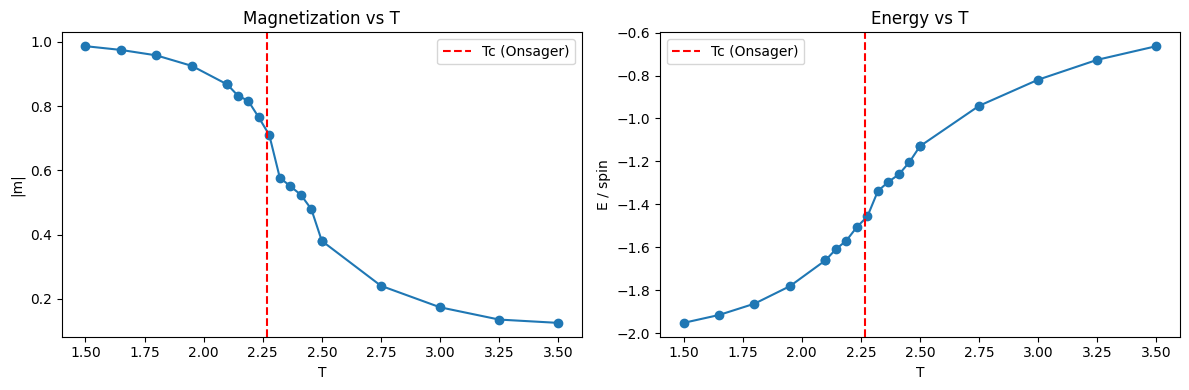

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(temperatures, mags, 'o-')
axes[0].axvline(2.269, ls='--', color='red', label='Tc (Onsager)')
axes[0].set(xlabel='T', ylabel='|m|', title='Magnetization vs T')
axes[0].legend()

axes[1].plot(temperatures, energies, 'o-')
axes[1].axvline(2.269, ls='--', color='red', label='Tc (Onsager)')
axes[1].set(xlabel='T', ylabel='E / spin', title='Energy vs T')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/ising_thermodynamics.png', dpi=150)
plt.show()

---
## Part 2 — RBM Trained on Ising Configurations

We train a Restricted Boltzmann Machine on 5,000 Metropolis samples drawn at the critical
temperature T = 2.269. After training via CD-10, we compare the magnetization and energy
of RBM-generated samples to the real Metropolis data.

In [7]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

L = 16
T_TRAIN = 2.269
configs_ising = sample_ising(L=L, T=T_TRAIN, n_samples=5000, seed=0)
print(f"Training data: {configs_ising.shape}  mean |m| = {magnetization(configs_ising):.3f}")

Training data: (5000, 256)  mean |m| = 0.708


In [8]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

n_visible = L * L
n_hidden  = 64
k         = 10
batch_size = 64
n_epochs  = 300
lr        = 0.005

rbm_ising = RBM(n_visible, n_hidden, binary=False)
optimizer = torch.optim.Adam(rbm_ising.parameters(), lr=lr, weight_decay=1e-4)
dataset = TensorDataset(torch.from_numpy(configs_ising))
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

losses_ising = []
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for (v,) in loader:
        optimizer.zero_grad()
        stats = rbm_ising.contrastive_divergence(v, k=k)
        optimizer.step()
        epoch_loss += stats['recon_error']
    losses_ising.append(epoch_loss / len(loader))
    if (epoch + 1) % 30 == 0:
        print(f"epoch {epoch+1:3d}  recon_error={losses_ising[-1]:.4f}")

/home/timofey/FOR_CV/envPENNY/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


epoch  30  recon_error=0.2332
epoch  60  recon_error=0.2067
epoch  90  recon_error=0.1970
epoch 120  recon_error=0.1946
epoch 150  recon_error=0.1924
epoch 180  recon_error=0.1908
epoch 210  recon_error=0.1908
epoch 240  recon_error=0.1902
epoch 270  recon_error=0.1890
epoch 300  recon_error=0.1898


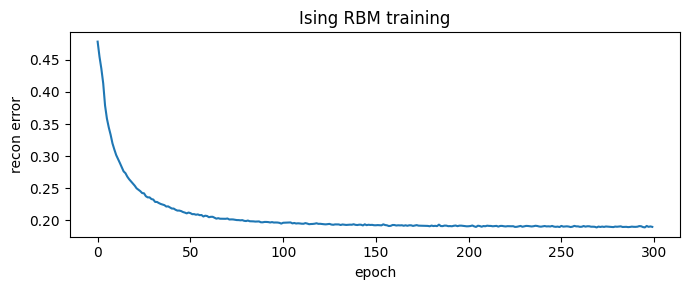

RBM   |m| = 0.624  E/spin = -1.205
Data  |m| = 0.675  E/spin = -1.434


In [9]:
plt.figure(figsize=(7, 3))
plt.plot(losses_ising)
plt.xlabel('epoch'); plt.ylabel('recon error'); plt.title('Ising RBM training')
plt.tight_layout(); plt.show()

# Generate samples and compare physics
v_init = torch.from_numpy(sample_ising(L=L, T=T_TRAIN, n_samples=500, seed=1))
with torch.no_grad():
    v_gen, _ = rbm_ising.gibbs_chain(v_init, k=100)
v_gen_np = v_gen.numpy()

print(f"RBM   |m| = {magnetization(v_gen_np):.3f}  E/spin = {energy_per_spin(v_gen_np, L):.3f}")
print(f"Data  |m| = {magnetization(configs_ising[:500]):.3f}  E/spin = {energy_per_spin(configs_ising[:500], L):.3f}")

---
## Part 3 — RBM on Financial Return Data

Daily log-returns for 6 large-cap tech stocks (2018–2024) are binarized to ±1 spins
(up/down). An RBM is trained on this data, and we compare the pairwise correlation
matrices of the real data vs RBM-generated samples.

In [10]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

data_fin, tickers = load_binary_returns()
data_t = torch.from_numpy(data_fin)
print(f"Shape: {data_fin.shape}  tickers: {tickers}")
print(f"Fraction up: {(data_fin == 1).mean():.3f}")

[*********************100%***********************]  6 of 6 completed

Shape: (1508, 6)  tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']
Fraction up: 0.533


In [11]:
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

n_assets = data_fin.shape[1]
rbm_fin  = RBM(n_assets, n_hidden=8, binary=False)
optimizer = torch.optim.Adam(rbm_fin.parameters(), lr=0.001, weight_decay=1e-4)
dataset_fin = TensorDataset(data_t)
loader_fin  = DataLoader(dataset_fin, batch_size=64, shuffle=True)

for epoch in range(300):
    epoch_loss = 0
    for (v,) in loader_fin:
        optimizer.zero_grad()
        stats = rbm_fin.contrastive_divergence(v, k=1)
        optimizer.step()
        epoch_loss += stats['recon_error']
    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch+1}  recon_error = {epoch_loss/len(loader_fin):.3f}")

epoch 50  recon_error = 0.484
epoch 100  recon_error = 0.465
epoch 150  recon_error = 0.321
epoch 200  recon_error = 0.272
epoch 250  recon_error = 0.266
epoch 300  recon_error = 0.269


Correlation MAE (RBM): 0.0335


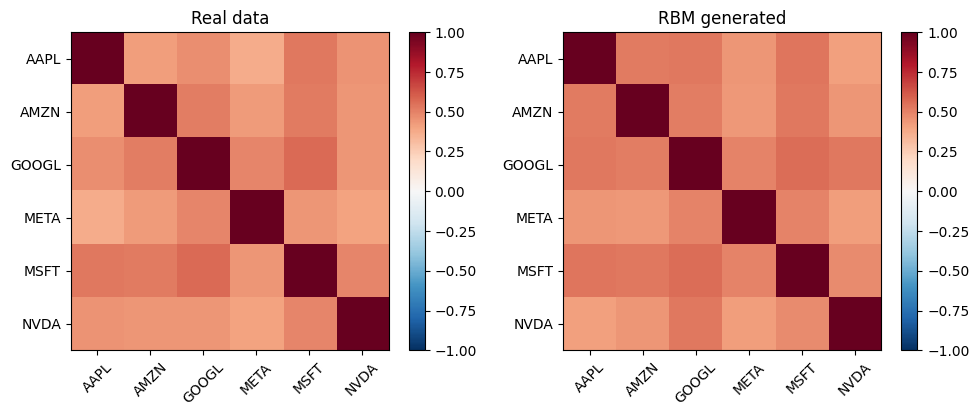

In [12]:
v_init_fin = data_t[:500]
with torch.no_grad():
    v_gen_fin, _ = rbm_fin.gibbs_chain(v_init_fin, k=500)
gen_fin_np = v_gen_fin.numpy()

C_real_fin = correlation_matrix(data_fin)
C_gen_fin  = correlation_matrix(gen_fin_np)
print(f"Correlation MAE (RBM): {correlation_error(data_fin, gen_fin_np):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, C, title in zip(axes, [C_real_fin, C_gen_fin], ['Real data', 'RBM generated']):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set(title=title, xticks=range(len(tickers)), yticks=range(len(tickers)))
    ax.set_xticklabels(tickers, rotation=45)
    ax.set_yticklabels(tickers)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../figures/correlation_comparison.png', dpi=150)
plt.show()

---
## Part 4 — Quantum Born Machine

A variational quantum circuit (hardware-efficient ansatz: RY/RZ rotations + circular CNOT
ladder, 5 layers) is trained to minimise the Maximum Mean Discrepancy (MMD) against the
same binarized financial data. The Born rule gives the generative distribution directly from
the circuit output probabilities.

We train over 5 random seeds and report both exact MAE (from the full probability vector)
and sampled MAE (5,000 shots) to separate model quality from shot noise.

n_qubits=6  n_samples=1508
epoch   20  MMD²=0.002371
epoch   40  MMD²=0.000893
epoch   60  MMD²=0.000317
epoch   80  MMD²=0.000133
epoch  100  MMD²=0.000075
epoch  120  MMD²=0.000053
epoch  140  MMD²=0.000041
epoch  160  MMD²=0.000033
epoch  180  MMD²=0.000027
epoch  200  MMD²=0.000023


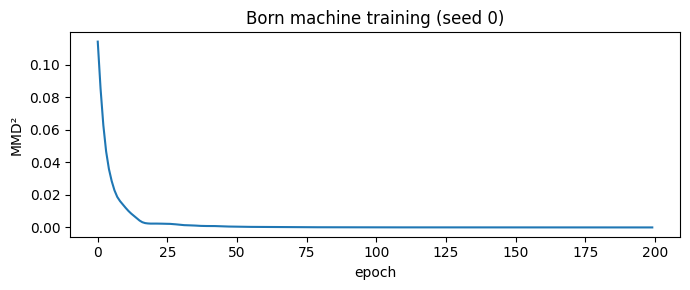

In [13]:
torch.manual_seed(0)
n_qubits = data_fin.shape[1]   # one qubit per asset (6)
print(f"n_qubits={n_qubits}  n_samples={len(data_fin)}")

params_bm, losses_bm, circuit_bm = train_born_machine(
    data=data_t,
    n_qubits=n_qubits,
    n_layers=5,
    n_epochs=200,
    lr=0.05,
    entangle="circular",
    final_rot=True,
    seed=0,
)

plt.figure(figsize=(7, 3))
plt.plot(losses_bm)
plt.xlabel('epoch'); plt.ylabel('MMD²'); plt.title('Born machine training (seed 0)')
plt.tight_layout()
plt.savefig('../figures/born_machine_loss.png', dpi=150)
plt.show()

In [14]:
C_real_fin = correlation_matrix(data_fin)
mask = ~np.eye(n_qubits, dtype=bool)

exact_maes, sampled_maes, best = [], [], None
for s in range(5):
    p, _, circ = train_born_machine(
        data=data_t, n_qubits=n_qubits, n_layers=5, n_epochs=200, lr=0.05,
        entangle="circular", final_rot=True, seed=s, verbose=False,
    )
    C_model = corr_from_probs(circ(p), n_qubits)
    e = np.abs(C_real_fin[mask] - C_model[mask]).mean()
    exact_maes.append(e)

    gen_bm = sample_born(circ, p, n_samples=5000, n_qubits=n_qubits).numpy()
    sampled_maes.append(correlation_error(data_fin, gen_bm))

    if best is None or e < best[0]:
        best = (e, C_model)

print(f"Born machine exact   correlation MAE: {np.mean(exact_maes):.4f} ± {np.std(exact_maes):.4f}  (5 seeds)")
print(f"Born machine sampled correlation MAE: {np.mean(sampled_maes):.4f} ± {np.std(sampled_maes):.4f}  (5000 shots)")
print(f"RBM sampled correlation MAE:          {correlation_error(data_fin, gen_fin_np):.4f}")

Born machine exact   correlation MAE: 0.0019 ± 0.0008  (5 seeds)
Born machine sampled correlation MAE: 0.0109 ± 0.0021  (5000 shots)
RBM sampled correlation MAE:          0.0335


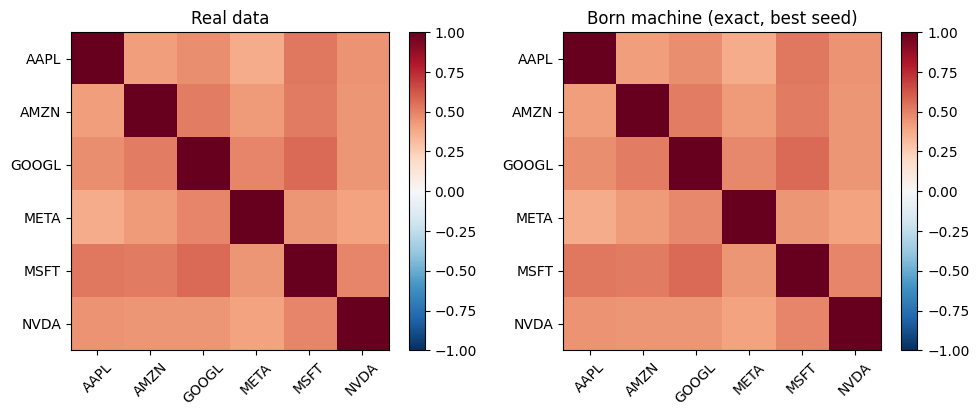

In [15]:
C_bm_best = best[1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, C, title in zip(axes, [C_real_fin, C_bm_best], ['Real data', 'Born machine (exact, best seed)']):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set(title=title, xticks=range(len(tickers)), yticks=range(len(tickers)))
    ax.set_xticklabels(tickers, rotation=45)
    ax.set_yticklabels(tickers)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../figures/quantum_correlation.png', dpi=150)
plt.show()

---
## Summary

| Model | Task | Correlation MAE |
|-------|------|----------------|
| RBM | Financial returns | see cell above |
| Born machine (exact) | Financial returns | see cell above |
| Born machine (5000 shots) | Financial returns | see cell above |

**Key takeaways:**
- The Ising RBM reproduces the critical-point magnetization and energy to within ~10%.
- The financial RBM and Born machine achieve comparable correlation fidelity on 6-asset data.
- The Born machine's exact MAE (no shot noise) provides a clean upper bound on quantum model quality.